### Logistic regression combined with Sentence-BERT for semantic embedding

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# read dataset
df = pd.read_excel("StackOverflow_security_sample_labelled.xlsx")
df_test = pd.read_excel("software_security_questions_100.xlsx") 
X_texts = df[["question"]].fillna("").agg(" ".join, axis=1).tolist()
y = df["Label1"]
XX_test = df_test["Question"]
YY_test = df_test["Label"]

# embeding
model = SentenceTransformer('all-MiniLM-L6-v2')
X_vec = model.encode(X_texts, show_progress_bar=True)
XXX = model.encode(XX_test, show_progress_bar=True)

# Calculate category weights
class_labels = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=class_labels, y=y)
class_weight_dict = dict(zip(class_labels, weights))

# Divide the dataset
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42, stratify=y)

# Using Logistic Regression Classifier
clf = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,        # Increase the number of iterations to avoid convergence problems
    solver='lbfgs',       
    multi_class='multinomial',
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("======== Original dataset test performance ======")
print(classification_report(y_test, y_pred))

y_pred1 = clf.predict(XXX)
print("======== External test set performance ======")
print(classification_report(YY_test, y_pred1))


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

======== Original dataset test performance ======
              precision    recall  f1-score   support

  Conceptual       0.54      0.71      0.61        21
   Debugging       0.77      0.72      0.74        60
      How-to       0.48      0.44      0.46        32

    accuracy                           0.64       113
   macro avg       0.60      0.62      0.60       113
weighted avg       0.64      0.64      0.64       113

======== External test set performance ======
              precision    recall  f1-score   support

  Conceptual       0.58      0.82      0.68        38
   Debugging       0.86      1.00      0.92        30
      How-to       0.50      0.19      0.27        32

    accuracy                           0.67       100
   macro avg       0.65      0.67      0.63       100
weighted avg       0.64      0.67      0.62       100



C:\Users\yifan\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Random Forest combined with Sentence-BERT for semantic embedding

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# Read dataset
df = pd.read_excel("StackOverflow_security_sample_labelled.xlsx")
df_test = pd.read_excel("software_security_questions_100.xlsx") 
X_texts = df[["title", "original question"]].fillna("").agg(" ".join, axis=1).tolist()
y = df["Label1"]
XX_test = df_test["Question"]
YY_test = df_test["Label"]

# embeding
model = SentenceTransformer('all-MiniLM-L6-v2')
X_vec = model.encode(X_texts, show_progress_bar=True)
XXX = model.encode(XX_test, show_progress_bar=True)

# Calculate category weights
class_labels = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=class_labels, y=y)
class_weight_dict = dict(zip(class_labels, weights))

# Divide the dataset
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=28, stratify=y)

# Using Random Forest Classifier
clf = RandomForestClassifier(
    n_estimators=100,              # Number of decision trees
    class_weight=class_weight_dict,
    random_state=28
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("======== Original dataset test performance ======")
print(classification_report(y_test, y_pred))

y_pred1 = clf.predict(XXX)
print("======== External test set performance ======")
print(classification_report(YY_test, y_pred1))


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

======== Original dataset test performance ======
              precision    recall  f1-score   support

  Conceptual       0.83      0.24      0.37        21
   Debugging       0.62      0.93      0.74        60
      How-to       0.69      0.34      0.46        32

    accuracy                           0.64       113
   macro avg       0.71      0.51      0.52       113
weighted avg       0.68      0.64      0.59       113

======== External test set performance ======
              precision    recall  f1-score   support

  Conceptual       0.71      0.58      0.64        38
   Debugging       0.53      1.00      0.69        30
      How-to       0.92      0.34      0.50        32

    accuracy                           0.63       100
   macro avg       0.72      0.64      0.61       100
weighted avg       0.72      0.63      0.61       100



### SVM combined with Sentence-BERT for semantic embedding

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# read dataset
df = pd.read_excel("StackOverflow_security_sample_labelled.xlsx")
df_test = pd.read_excel("software_security_questions_100.xlsx") 
#df_test = pd.read_excel("question.xlsx") 
#df = pd.read_csv("classified_questions.csv")
#X_texts = df[["title","new_question"]].fillna("").agg(" ".join, axis=1).tolist()
X_texts = df[["title","original question"]].fillna("").agg(" ".join, axis=1).tolist()
#X_texts = df[["title","question"]].fillna("").agg(" ".join, axis=1).tolist()
y = df["Label1"]
#y = df['category']
#print(df["Label1"].value_counts())
XX_test = df_test["Question"]
YY_test = df_test["Label"]
# print(df_test.columns)
# XX_test = df_test["question_title"]
# YY_test = df_test["question_type"]

# embeding
model = SentenceTransformer('all-MiniLM-L6-v2')
X_vec = model.encode(X_texts, show_progress_bar=True)
XXX = model.encode(XX_test, show_progress_bar=True)
# Calculate category weights
class_labels = np.unique(y)
print(class_labels)
weights = compute_class_weight(class_weight="balanced", classes=class_labels, y=y)
print(weights)
class_weight_dict = dict(zip(class_labels, weights))

# Divide the dataset
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=28, stratify=y)

#Training SVM with class weights
clf = LinearSVC(class_weight=class_weight_dict)
clf.fit(X_train, y_train)

# Prediction and evaluation

y_pred = clf.predict(X_test)
print("======== Original dataset test performance ======")
print(classification_report(y_test, y_pred))

# label_map = {1: "Conceptual", 2: "How-to", 3: "Debugging"}
# YY_test = YY_test.map(label_map)

y_pred1 = clf.predict(XXX)
print("======== External test set performance ======")
print(classification_report(YY_test, y_pred1))

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

['Conceptual' 'Debugging' 'How-to']
[1.78095238 0.63282572 1.16510903]
======== Original dataset test performance ======
              precision    recall  f1-score   support

  Conceptual       0.59      0.62      0.60        21
   Debugging       0.83      0.87      0.85        60
      How-to       0.64      0.56      0.60        32

    accuracy                           0.73       113
   macro avg       0.69      0.68      0.68       113
weighted avg       0.73      0.73      0.73       113

======== External test set performance ======
              precision    recall  f1-score   support

  Conceptual       0.69      0.97      0.80        38
   Debugging       1.00      1.00      1.00        30
      How-to       0.94      0.47      0.62        32

    accuracy                           0.82       100
   macro avg       0.87      0.81      0.81       100
weighted avg       0.86      0.82      0.81       100



### SVM combined with TF-IDF text embedding

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# Reading Data
df = pd.read_excel("StackOverflow_security_sample_labelled.xlsx")
X_texts = df[["title","new_question"]].fillna("").agg(" ".join, axis=1).tolist()
#X_texts = df[["title","original question"]].fillna("").agg(" ".join, axis=1).tolist()
#X_texts = df[["original question"]].fillna("").agg(" ".join, axis=1).tolist()
y = df["Label1"]



# embeding
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # 可调参数
X_vec = vectorizer.fit_transform(X_texts)

# calculate category weights
class_labels = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=class_labels, y=y)
class_weight_dict = dict(zip(class_labels, weights))

# divide dataset
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)

# Training SVM with class weights
clf = LinearSVC(class_weight=class_weight_dict)
#clf = LinearSVC()
clf.fit(X_train, y_train)

# Prediction and evaluation
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

  Conceptual       0.38      0.30      0.33        20
   Debugging       0.68      0.88      0.77        64
      How-to       0.40      0.21      0.27        29

    accuracy                           0.60       113
   macro avg       0.49      0.46      0.46       113
weighted avg       0.56      0.60      0.56       113



## Unsupervised LDA

### Process the original title (consistent with the method in the paper)

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup

# Download nltk resources (only needed for the first time)
nltk.download('stopwords')

# Loading a raw Excel file
df = pd.read_csv("StackOverflow_lda_labelled.csv")

# Delete rows where the orig column is empty
df = df.dropna(subset=['original question'])

# Initialization Tool
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Text preprocessing functions
def preprocess_text(text):
    # Convert to string
    text = str(text)

    # Step 1: Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Step 2: Remove code snippets, special symbols, numbers, and punctuation
    text = re.sub(r'<code>.*?</code>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Lowercase, word segmentation, stop word removal, stemming
    words = text.lower().split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    # Step 4: Remove words that are too long or too short
    words = [word for word in words if 2 <= len(word) <= 12]

    return ' '.join(words)

# Apply the processing function and create the new_question column
df['processed_question'] = df['original question'].apply(preprocess_text)

# Save as a new file or overwrite the original file
df.to_csv("StackOverflow_lda_labelled.csv", index=False)

print("Preprocessing completed and saved to file")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yifan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\yifan\AppData\Local\Temp\ipykernel_45712\1864774499.py:27: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()
F:\ANACONDA\Lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


预处理完成，已保存到文件中


### Start LDA

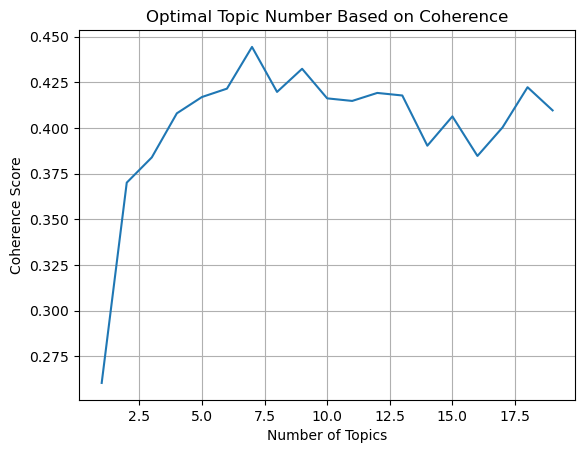


The optimal number of model topics is：7, Coherence score is：0.4444

Topic 0：0.017*"cooki" + 0.011*"page" + 0.010*"get" + 0.009*"open" + 0.009*"name" + 0.008*"letter" + 0.008*"imag" + 0.007*"script" + 0.007*"python" + 0.007*"true"
Topic 1：0.030*"password" + 0.023*"user" + 0.018*"login" + 0.016*"use" + 0.011*"usernam" + 0.010*"code" + 0.009*"get" + 0.008*"tri" + 0.008*"page" + 0.008*"authent"
Topic 2：0.030*"script" + 0.014*"servic" + 0.012*"credenti" + 0.012*"run" + 0.009*"secur" + 0.009*"want" + 0.009*"download" + 0.009*"web" + 0.008*"list" + 0.008*"file"
Topic 3：0.042*"string" + 0.019*"cipher" + 0.017*"ae" + 0.012*"test" + 0.011*"item" + 0.010*"def" + 0.009*"let" + 0.009*"return" + 0.009*"nsstring" + 0.008*"event"
Topic 4：0.036*"public" + 0.028*"null" + 0.019*"class" + 0.018*"return" + 0.018*"new" + 0.018*"string" + 0.016*"except" + 0.016*"void" + 0.013*"privat" + 0.012*"throw"
Topic 5：0.045*"new" + 0.040*"byte" + 0.036*"key" + 0.028*"string" + 0.026*"return" + 0.025*"public" + 0.024*

In [3]:
import pandas as pd
from gensim import corpora, models
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Step 1: Load the data
df = pd.read_csv("StackOverflow_lda_labelled.csv")

# Step 2: Use the processed question column to perform word segmentation
df['tokens'] = df['processed_question'].astype(str).apply(lambda x: x.split())

# Step 3: Building a dictionary and corpus
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# Step 4: Define functions for training multiple topic models and calculating Coherence
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    models_list = []
    coherence_scores = []

    for num_topics in range(start, limit, step):
        model = models.LdaModel(corpus=corpus,id2word=dictionary,num_topics=num_topics,random_state=42,chunksize=100,passes=10,alpha='auto',eta='auto')
        models_list.append(model)

        coherencemodel = CoherenceModel(model=model,texts=texts,dictionary=dictionary,coherence='c_v')
        coherence_scores.append(coherencemodel.get_coherence())
    return models_list, coherence_scores

# Step 5: Start parameter adjustment search (number of topics from 1 to 20)
lda_models, coherence_values = compute_coherence_values(dictionary=dictionary,corpus=corpus,texts=df['tokens'],start=1,limit=20,step=1)

# Step 6: Plotting the optimal number of topics
x = range(1, 20)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Topic Number Based on Coherence")
plt.grid(True)
plt.show()

# Step 7: Output the best model and its topic keywords
best_index = coherence_values.index(max(coherence_values))
best_model = lda_models[best_index]
print(f"\nThe optimal number of model topics is：{x[best_index]}, Coherence score is：{coherence_values[best_index]:.4f}\n")

# Display the subject keywords of this model
topics = best_model.print_topics(num_words=10)
for i, topic in topics:
    print(f"Topic {i}：{topic}")

In [24]:
best_model = lda_models[6]

### Create a json file with subcategories and major categories corresponding to topics

In [25]:
import json

topic_mapping = {
    "0": {"subcategory": "Page Interaction", "category": "Access Control"},
    "1": {"subcategory": "Authentication", "category": "Access Control"},
    "2": {"subcategory": "Credential Handling", "category": "Access Control"},
    "3": {"subcategory": "Cipher Implementation", "category": "Cryptography"},
    "4": {"subcategory": "Exception Handling", "category": "Secure Development"},
    "5": {"subcategory": "Key and Encryption", "category": "Cryptography"},
    "6": {"subcategory": "Server Communication", "category": "Network Security"}
}

# {
#   "0": {"subcategory": "Web Interface Handling", "category": "Access Control"},
#   "1": {"subcategory": "Authentication", "category": "Access Control"},
#   "2": {"subcategory": "Web Security & Credential Usage", "category": "Network Security"},
#   "3": {"subcategory": "Cipher Implementation", "category": "Cryptography"},
#   "4": {"subcategory": "Exception Handling", "category": "Secure Development"},
#   "5": {"subcategory": "Key and Encryption Handling", "category": "Cryptography"},
#   "6": {"subcategory": "Server-Side Encryption & Certificate", "category": "Network Security"}
# }
with open("topic_category_mapping.json", "w", encoding="utf-8") as f:
    json.dump(topic_mapping, f, ensure_ascii=False, indent=2)

print("Topic-to-category mapping saved.")




Topic-to-category mapping saved.


### The original data is named into subcategories and major categories according to the topic of LDA and saved into files

In [26]:
import json
dominant_topics = [max(best_model.get_document_topics(bow), key=lambda x: x[1])[0] for bow in corpus]

df["topic_id"] = dominant_topics

with open("topic_category_mapping.json", "r", encoding="utf-8") as f:
    topic_mapping = json.load(f)

df["subcategory"] = df["topic_id"].astype(str).map(lambda x: topic_mapping.get(x, {}).get("subcategory", "Unknown"))
df["category"] = df["topic_id"].astype(str).map(lambda x: topic_mapping.get(x, {}).get("category", "Unknown"))
#df.to_csv("StackOverflow111.csv", index=False,encoding="utf-8")
df.drop(columns=["tokens"], errors='ignore').to_csv("StackOverflow222.csv", index=False, encoding="utf-8")
print("已经保存新分类文件")


已经保存新分类文件


### How many original posts does each topic have?

In [17]:
from collections import Counter

# Count the main topic of each document (topic with the highest probability)
dominant_topic_list = []

for bow in corpus:
    topic_distribution = best_model.get_document_topics(bow)
    dominant_topic = max(topic_distribution, key=lambda x: x[1])[0]
    dominant_topic_list.append(dominant_topic)

# Statistical frequency
topic_counter = Counter(dominant_topic_list)

# Save as a text file
with open("topic_frequence.txt", "w", encoding="utf-8") as f:
    for topic_id in range(best_model.num_topics):
        freq = topic_counter.get(topic_id, 0)
        line = f"{topic_id}\t{freq}"
        print(line)
        f.write(line + "\n")


0	26
1	165
2	28
3	15
4	27
5	35
6	78


### Clean and store the words under each topic

In [18]:
# 假设你已有最佳模型：best_model
# 设置参数：每个 topic 保留的关键词数
num_words = 10

# 打开文件准备写入
with open("topic.txt", "w", encoding="utf-8") as f:
    for topic_id in range(best_model.num_topics):
        # 获取当前 topic 的 top-n 关键词列表
        topic_terms = best_model.show_topic(topic_id, topn=num_words)
        
        # 提取关键词（去掉概率值）
        keywords = [word for word, prob in topic_terms]
        
        # 拼接为字符串
        topic_line = f"Topic {topic_id}: " + " ".join(keywords)
        
        # 打印并写入文件
        print(topic_line)
        f.write(topic_line + "\n")


Topic 0: cooki page get open name letter imag script python true
Topic 1: password user login use usernam code get tri page authent
Topic 2: script servic credenti run secur want download web list file
Topic 3: string cipher ae test item def let return nsstring event
Topic 4: public null class return new string except void privat throw
Topic 5: new byte key string return public encrypt privat int var
Topic 6: use encrypt file key server certif im work client need


### save model

In [19]:
# path
model_path = f"lda_model_best_{x[best_index]}topics"
dictionary_path = "lda_dictionary.dict"

# save the best LDA model
best_model.save(f"{model_path}.model")

# Save dictionary (id2word)
dictionary.save(dictionary_path)

print(f"模型已保存至：{model_path}.model")


模型已保存至：lda_model_best_7topics.model


### Using models to classify security aspects of user input questions

In [20]:

import json
import re
from gensim import corpora, models
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup
import nltk
import os

# Initialization runs only once
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Model and dictionary paths
MODEL_PATH = 'lda_model_best_7topics.model'
DICT_PATH = 'lda_dictionary.dict'
MAPPING_PATH = 'topic_category_mapping.json'

# Loading the model and dictionary
loaded_model = models.LdaModel.load(MODEL_PATH)
loaded_dict = corpora.Dictionary.load(DICT_PATH)

# Loading topic-category mapping
try:
    with open(MAPPING_PATH, "r", encoding="utf-8") as f:
        topic_mapping = json.load(f)
except:
    topic_mapping = {}

# Text preprocessing functions
def preprocess_text(text):
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'<code>.*?</code>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.lower().split()
    words = [stemmer.stem(w) for w in words if w not in stop_words and 2 <= len(w) <= 12]
    return ' '.join(words)

# Classification main function
def classify_question(question):
    tokens = preprocess_text(question).split()
    bow = loaded_dict.doc2bow(tokens)
    topic_dist = loaded_model.get_document_topics(bow)

    if not topic_dist:
        return {
            "topic_id": None,
            "subcategory": "Unknown",
            "category": "Unknown",
            "distribution": []
        }

    best_topic = max(topic_dist, key=lambda x: x[1])[0]

    topic_info = topic_mapping.get(str(best_topic), {"subcategory": "Unknown", "category": "Unknown"})
    sub_cat = topic_info["subcategory"]
    main_cat = topic_info["category"]

    return {
        "topic_id": best_topic,
        "subcategory": sub_cat,
        "category": main_cat,
        "distribution": topic_dist
    }


    
test_question = classify_question("How to prevent SQL injection in Java web app?")
print(f"\nYour question is categorized under the main category: {test_question['category']}, and the subcategory: {test_question['subcategory']}.")
print("This may be your knowledge blind spot, it is recommended that you learn more and pay attention to such security issues in the future.")


Your question is categorized under the main category: Access Control, and the subcategory: Authentication.
This may be your knowledge blind spot, it is recommended that you learn more and pay attention to such security issues in the future.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yifan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
